In [1]:
import pandas as pd
import seaborn as srn
import statistics as sts

In [2]:
#Importar dados
dadosTempo = pd.read_csv("tempo.csv", sep = ";")
#Visualizar
dadosTempo.head()

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85,85.0,FALSO,nao
1,sol,80,90.0,VERDADEIRO,nao
2,nublado,83,86.0,FALSO,sim
3,chuva,70,NaN,FALSO,sim
4,chuva,68,80.0,FALSO,sim


In [3]:
#Tamanho
dadosTempo.shape

(14, 5)

In [4]:
#Explorar dados por categoria (começando com dados categóricos)
#Aparencia
agrupado = dadosTempo.groupby(["Aparencia"]).size()
agrupado

Aparencia
chuva      5
menos      1
nublado    3
sol        5
dtype: int64

<Axes: xlabel='Aparencia'>

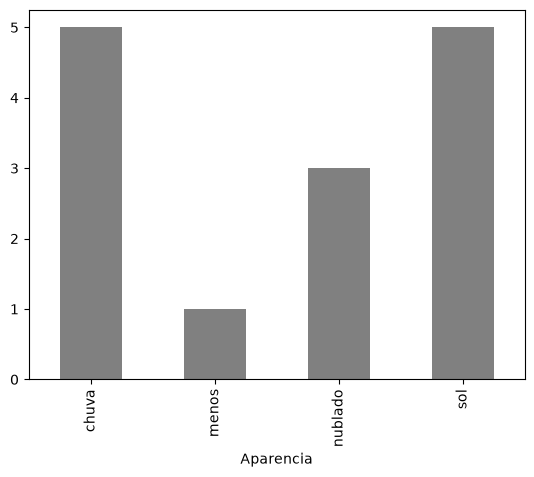

In [5]:
#Visualização da coluna Aparencia através de um gráfico de barras
agrupado.plot.bar(color = 'gray')

In [6]:
#Vento
agrupado = dadosTempo.groupby(["Vento"]).size()
agrupado

Vento
FALSO         7
VERDADEIRO    6
dtype: int64

<Axes: xlabel='Vento'>

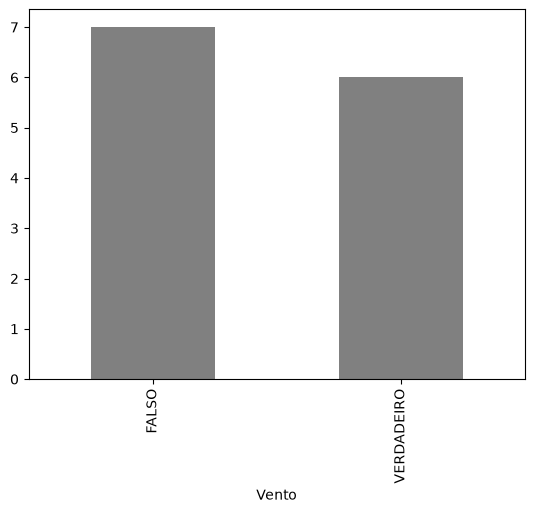

In [7]:
#Visualização da coluna "Vento" em gráfico de barras
agrupado.plot.bar(color = "gray")

In [8]:
#Jogar
agrupado = dadosTempo.groupby(["Jogar"]).size()
agrupado

Jogar
nao    5
sim    9
dtype: int64

<Axes: xlabel='Jogar'>

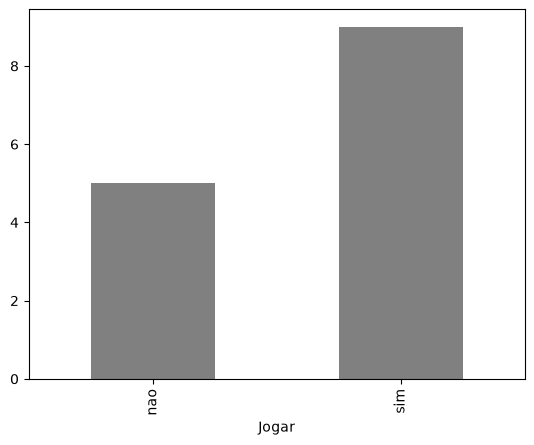

In [9]:
#Visualização da coluna "Jogar" em gráfico de barras
agrupado.plot.bar(color = "gray")

Agora vamos começar a explar os dados numéricos

In [10]:
#Temperatura
dadosTempo["Temperatura"].describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

Text(0.5, 1.0, 'Temperatura')

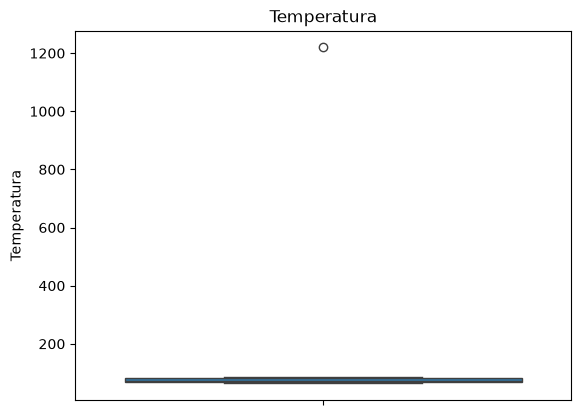

In [11]:
#Visualização da coluna "Temperatura" em um gráfico de boxplot
srn.boxplot(dadosTempo['Temperatura']).set_title('Temperatura')

In [12]:
#Umidade
dadosTempo["Umidade"].describe()

count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

In [13]:
#Umidade
dadosTempo['Umidade'].describe()

count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

Text(0.5, 1.0, 'Umidade')

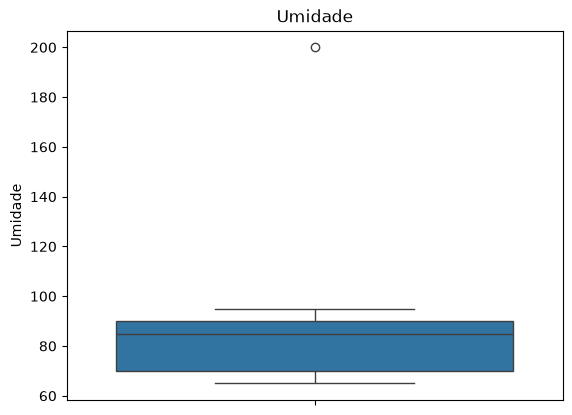

In [14]:
#Visualização da coluna Umidade em um boxplot
srn.boxplot(dadosTempo['Umidade']).set_title('Umidade')

Text(0.5, 1.0, 'Umidade')

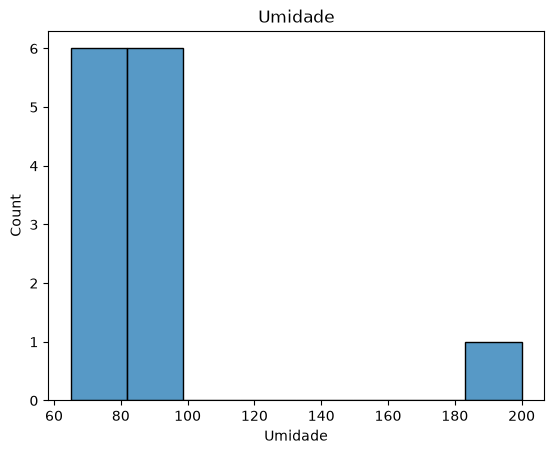

In [15]:
srn.histplot(dadosTempo['Umidade']).set_title('Umidade')

In [16]:
#Contagem de valores NAs
dadosTempo.isnull().sum()

Aparencia      0
Temperatura    0
Umidade        1
Vento          1
Jogar          0
dtype: int64

Tratamento nos dados
1. Tratar valor fora de domínio em Umidade e valor NA em Umidade (ok)
2. Tratar valor NA em vento (ok)
3. Tratar valor fora do padrão em aparência (ok)
4. Tratar valor outlier em Temperatura

In [17]:
#Tratamento de valor NA em Umidade
dadosTempo['Umidade'].isna().sum()

np.int64(1)

In [18]:
#mediana
mediana = sts.median(dadosTempo['Umidade'])
mediana

85.5

In [19]:
#Substituindo
dadosTempo['Umidade'] = dadosTempo['Umidade'].fillna(mediana)

In [20]:
#Visualizando novamente valores NAs
dadosTempo['Umidade'].isna().sum()

np.int64(0)

In [21]:
#Tratamento dos valores fora de domínio em Umidade
dadosTempo.loc[(dadosTempo['Umidade'] < 0) | (dadosTempo['Umidade'] > 100)]

,Aparencia,Temperatura,Umidade,Vento,Jogar
9,chuva,75,200.0,NaN,sim


In [22]:
#Substituir valores fora de domínio pela mediana
dadosTempo.loc[(dadosTempo['Umidade'] < 0) | (dadosTempo['Umidade'] > 100), 'Umidade'] = mediana

In [23]:
#Visualizando novamente valores fora de domínio em Umidade
dadosTempo.loc[(dadosTempo['Umidade'] < 0) | (dadosTempo['Umidade'] > 100)]

,Aparencia,Temperatura,Umidade,Vento,Jogar


In [24]:
#Tratando valores NA em vento
dadosTempo['Vento'].isna().sum()
agrupado = dadosTempo.groupby(['Vento']).size()
agrupado

Vento
FALSO         7
VERDADEIRO    6
dtype: int64

In [25]:
#Verificando a moda
agrupado = dadosTempo.groupby(['Vento']).size()
agrupado

Vento
FALSO         7
VERDADEIRO    6
dtype: int64

In [26]:
#Substituindo valor NA pela moda
dadosTempo.loc[dadosTempo['Vento'].isna(), 'Vento'] = 'FALSO'

In [27]:
#Tratar valor fora de padrão em Aparência
agrupado = dadosTempo.groupby(["Aparencia"]).size()
agrupado

Aparencia
chuva      5
menos      1
nublado    3
sol        5
dtype: int64

In [28]:
#Substituir valor categórico "Menos" e "FALSO" pela moda, nesse caso é bimodal,
#Sendo bimodal a escolha será por ondem alfabética, então será "Chuva"
dadosTempo.loc[dadosTempo['Aparencia'].isin(['FALSO', 'menos']), 'Aparencia'] = 'chuva'

In [29]:
#Visualizar se os valores categóricos foram alterados
agrupado = dadosTempo.groupby(["Aparencia"]).size()
agrupado

Aparencia
chuva      6
nublado    3
sol        5
dtype: int64

In [30]:
#Tratar valor outlier em temperatua
dadosTempo['Temperatura'].describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

In [31]:
#Gerar variável com desvio padrão
desv = sts.stdev(dadosTempo['Temperatura'])
desv

306.433758505241

In [32]:
#Verificando se o valor está 2 vezes o valor do desvio padrão
dadosTempo.loc[dadosTempo['Temperatura'] >= 2 * desv]

,Aparencia,Temperatura,Umidade,Vento,Jogar
7,sol,1220,95.0,FALSO,nao


In [ ]:
#calcular mediana e arredondar para o padrão da coluna
mediana = round(sts.median(dadosTempo['Temperatura']))
mediana

74

In [34]:
#Substituir o valor outlier pela mediana
dadosTempo.loc[dadosTempo['Temperatura'] >= 2 * desv, 'Temperatura'] = mediana

In [ ]:
#Verificando alteração do valor outlier
dadosTempo['Temperatura'].describe()

count    14.000000
mean     73.714286
std       6.556601
min      64.000000
25%      69.250000
50%      73.000000
75%      78.750000
max      85.000000
Name: Temperatura, dtype: float64